# RTM3 main-paper reproduction

This notebook reruns the 100,000-participant simulation with fixed seeds, generates both manuscript images through shared functions, and embeds the figures and source results. Figure 1 is calculated from outcomes; Figure 2 is conceptual. The Appendix contains equations and sensitivity analyses. The archived `old_for_rtm3_paper.ipynb` is not a source of current results.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display
from reproduce_rtm3 import run_analysis, make_main_figure, DEFAULT_SEED
from rtm3_reporting import load_results, show_outcomes, make_conceptual_figure, validate_artifacts
OUTPUT = Path('results')

In [2]:
paths = run_analysis(n_patients=100_000, seed=DEFAULT_SEED, output_dir=OUTPUT, progress_every=25_000)
results = load_results(OUTPUT)

RTM3 canonical run: N=100,000; base seed=20260813


Generated 25,000/100,000 latent participants


Generated 50,000/100,000 latent participants


Generated 75,000/100,000 latent participants


Generated 100,000/100,000 latent participants


Latent cohort generated in 24.4 seconds


Validation: PASS
{
  "status": "PASS",
  "perfect_detector_condition_identical_between_sweeps": true,
  "exact_oracle_invariant_across_FAR": true,
  "primary_rows": 21,
  "fixed_cohort_size_invariant": true,
  "fixed_and_reselected_perfect_detector_match": true,
  "MPC_denominators_complete": true,
  "additive_raw_thresholds_equivalent_to_primary": true,
  "max_absolute_MPC_difference_primary_vs_original_25day_pp": 2.288329519450791,
  "max_absolute_observed_RTM_difference_primary_vs_original_25day_pp": 2.491850280183833,
  "max_absolute_eligibility_difference_primary_vs_original_25day_pp": 2.2840000000000025
}
Outputs written to /Users/dgoldenh/Documents/GitHub/RTM3/results


## Figure 1

The saved PNG and TIFF are the generated image used in the manuscript and submission files. Error bars describe uncertainty in the median, not variation among individuals.

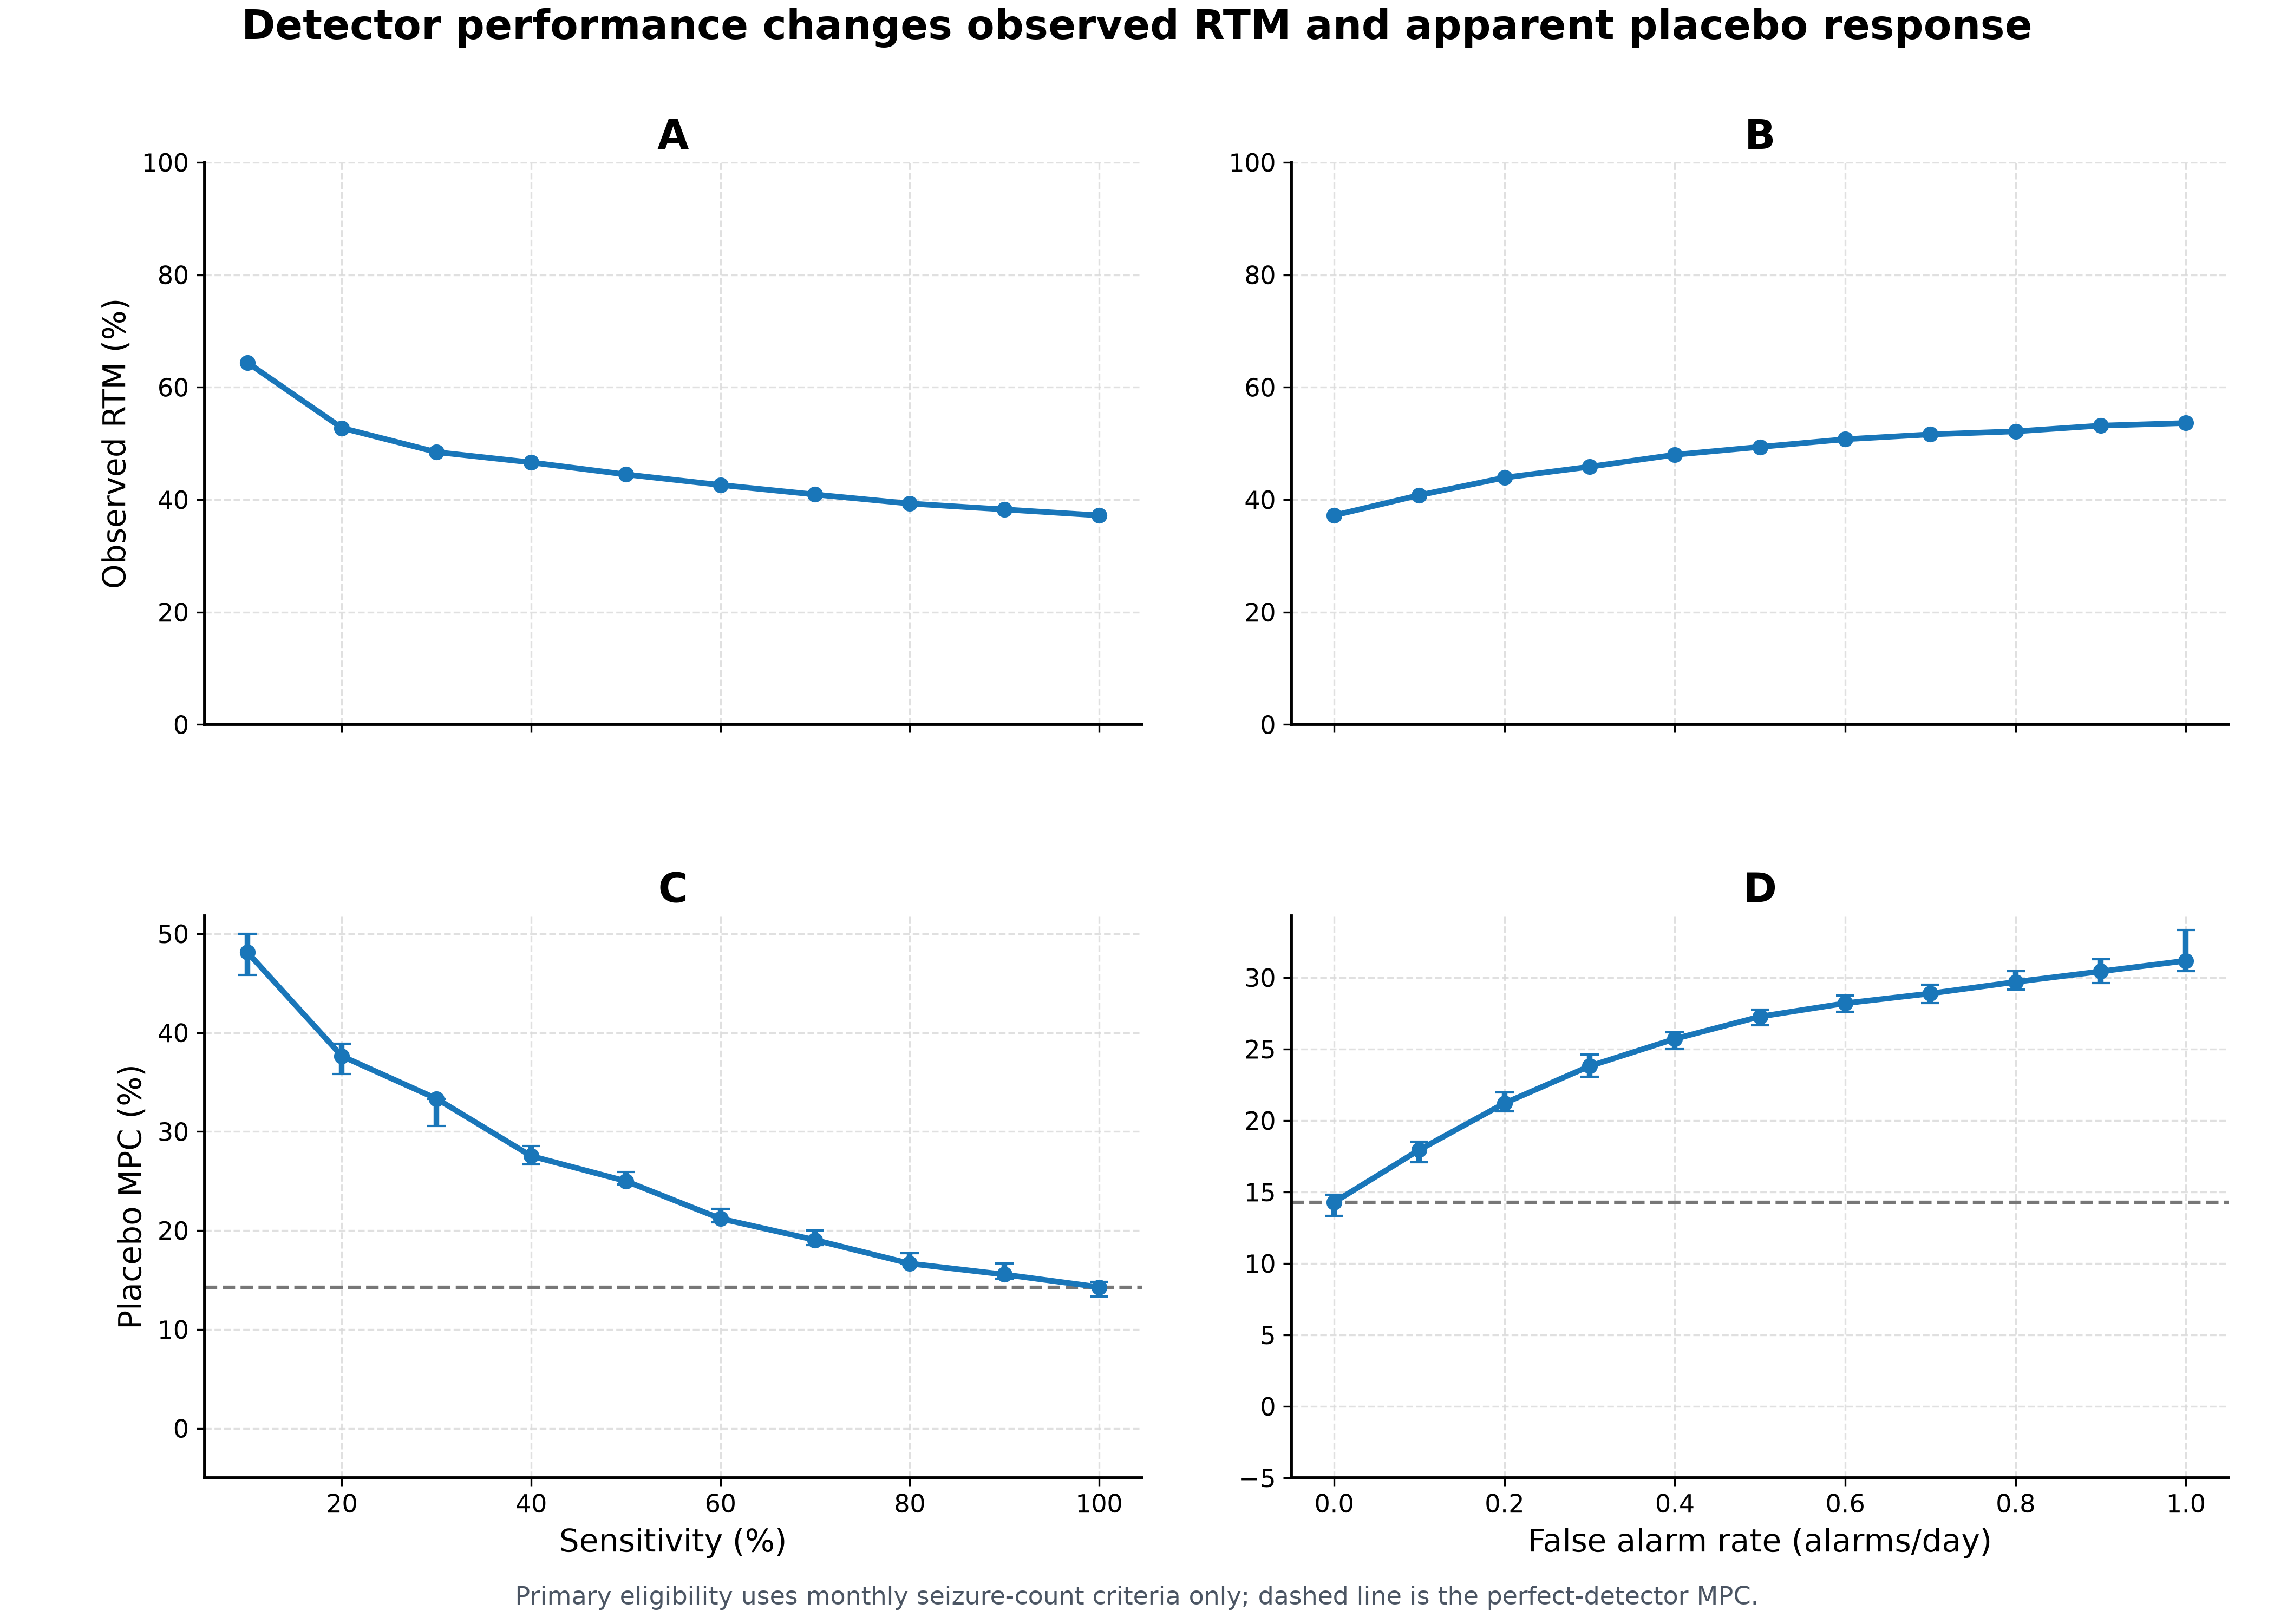

In [3]:
make_main_figure(results['primary'], OUTPUT)
plt.close('all')
display(Image(filename=str(OUTPUT / 'figure1_sensitivity_and_FAR_vs_RTM_mpc_ci.png')))

## Figure 2

The diagram separates changes in cohort membership from changes in measured trajectories. It contains no estimated effect sizes or causal decomposition.

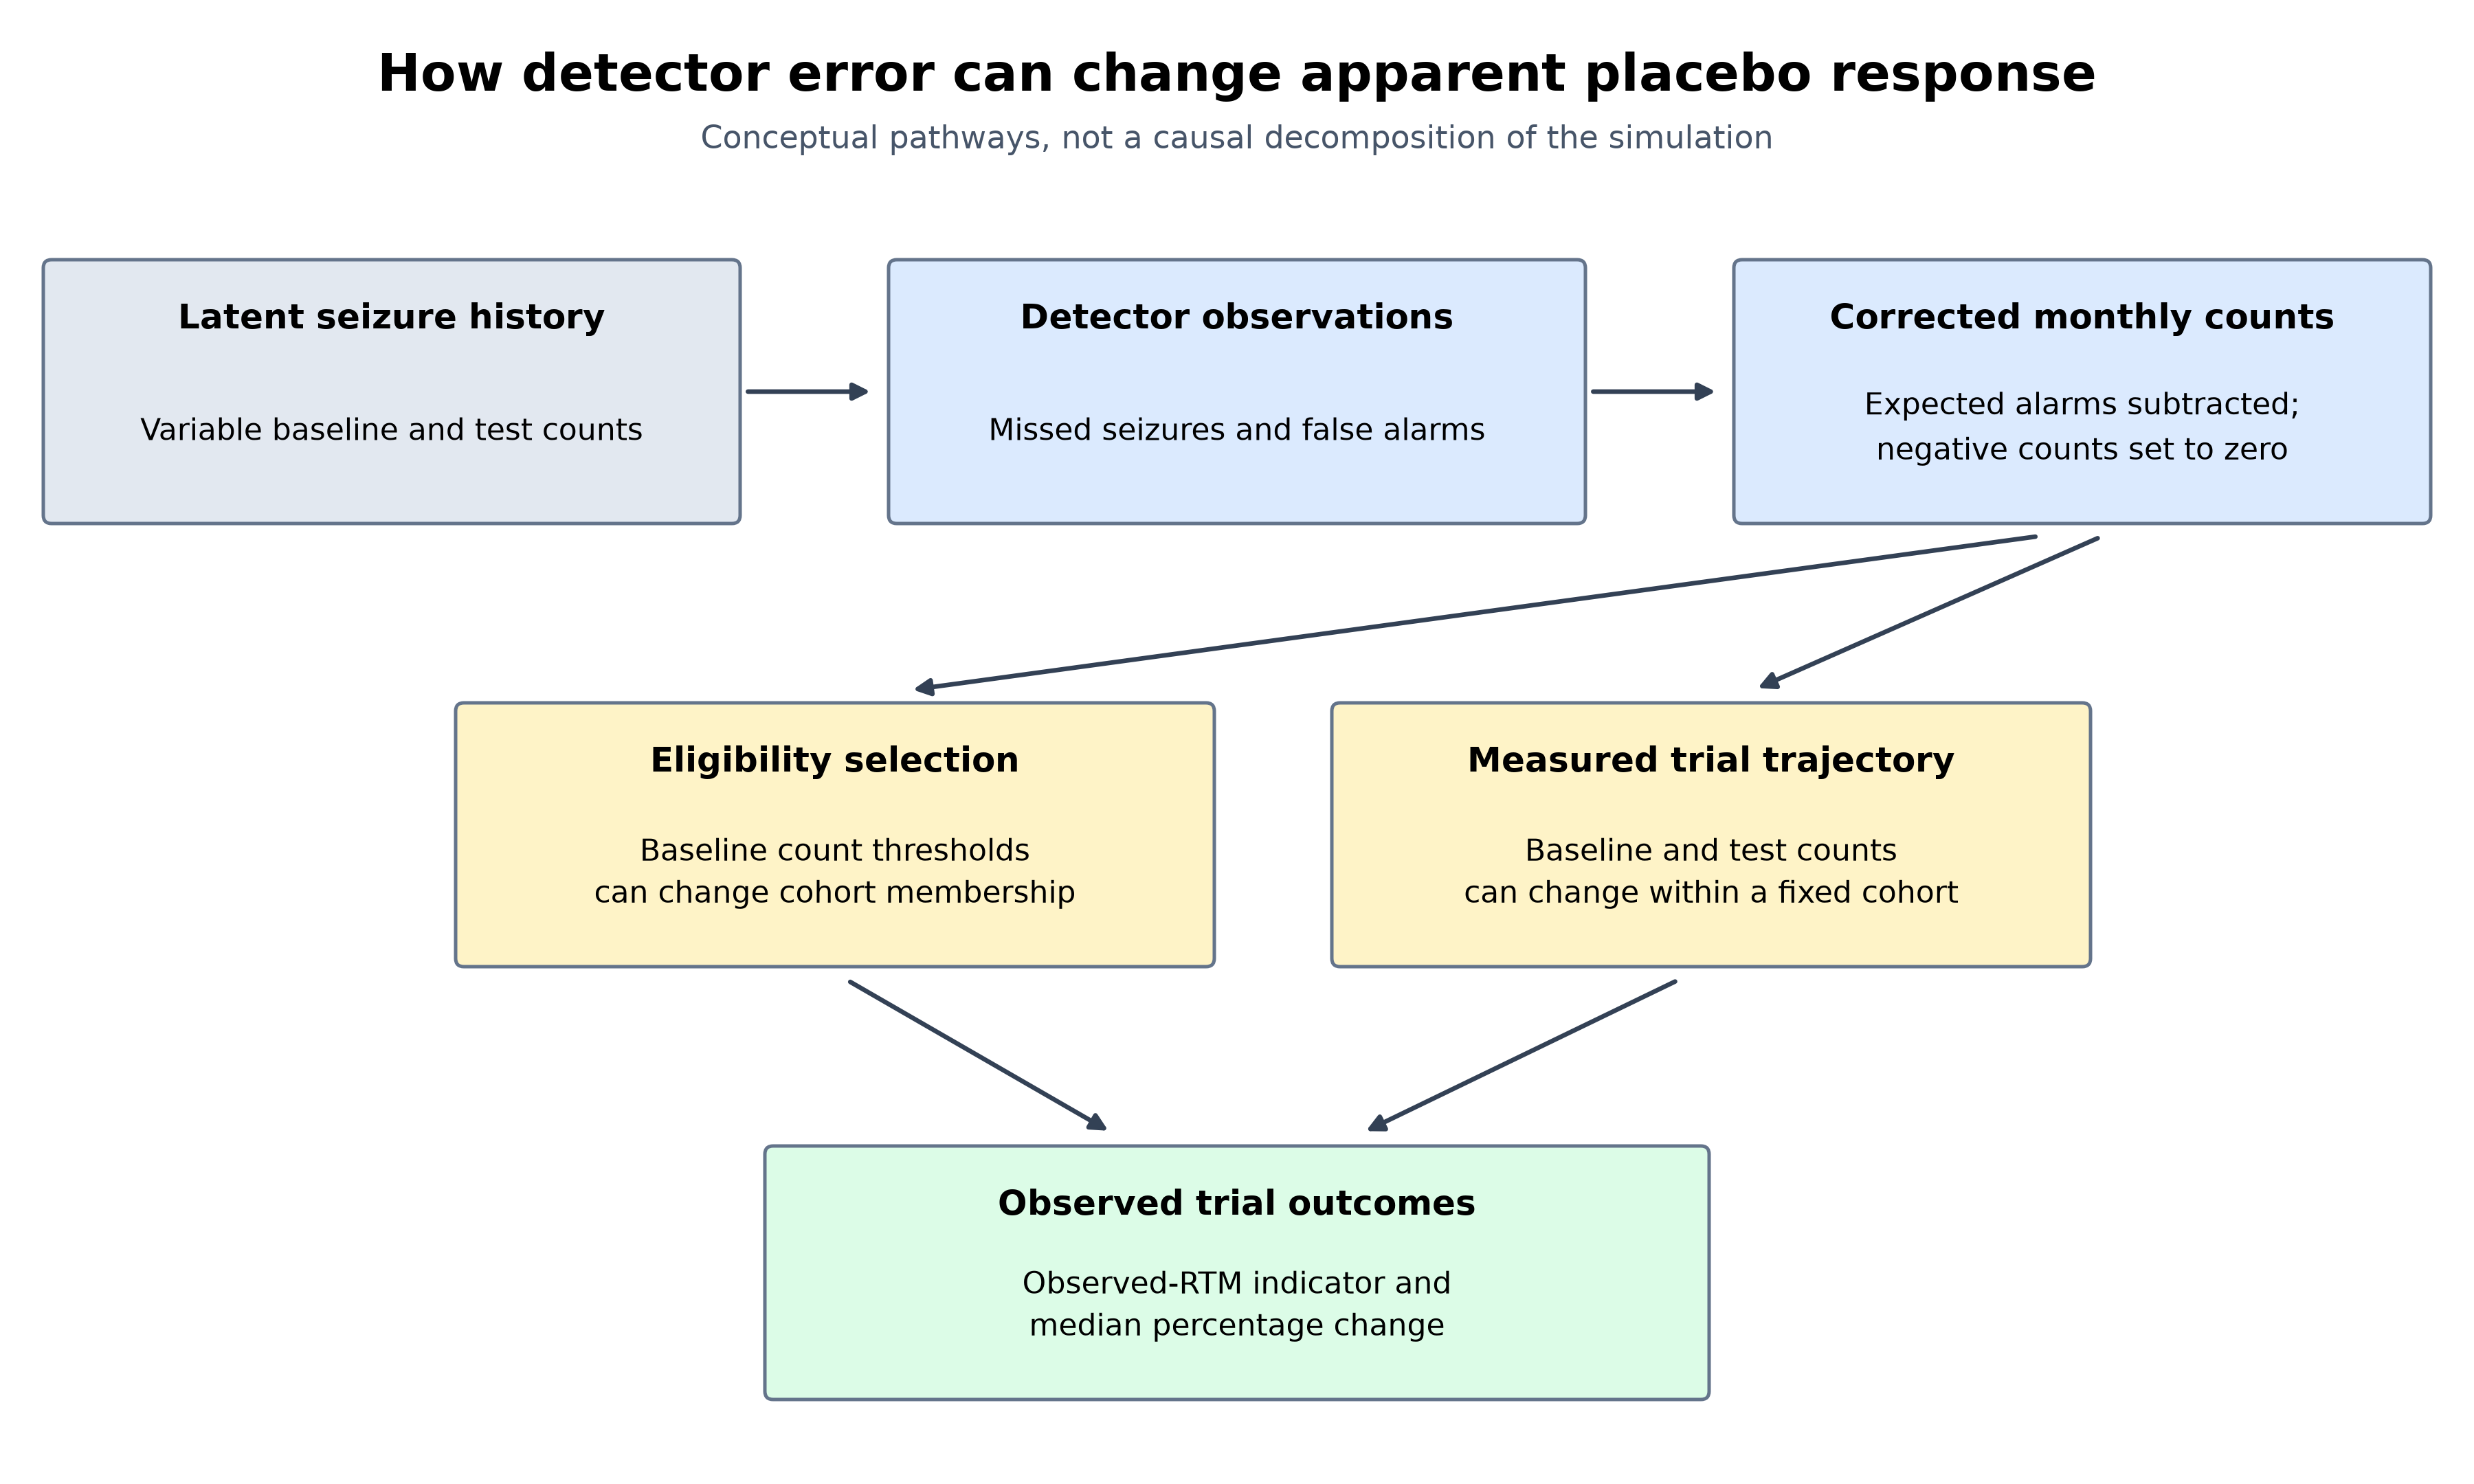

In [4]:
make_conceptual_figure(OUTPUT)
plt.close('all')
display(Image(filename=str(OUTPUT / 'figure2_conceptual_mechanism.png')))

## Figure 1 source values

In [5]:
show_outcomes(results['primary'])

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
Sensitivity 10%,2180,2.18,64.40,48.15,45.83 to 50.00,2180,0
Sensitivity 20%,5955,5.96,52.76,37.63,35.80 to 38.89,5955,0
Sensitivity 30%,9824,9.82,48.46,33.33,30.56 to 33.33,9824,0
Sensitivity 40%,13845,13.84,46.63,27.54,26.67 to 28.57,13845,0
Sensitivity 50%,17865,17.87,44.49,25.00,24.64 to 25.93,17865,0
Sensitivity 60%,21790,21.79,42.62,21.21,20.83 to 22.22,21790,0
Sensitivity 70%,25546,25.55,40.92,19.05,18.52 to 20.00,25546,0
Sensitivity 80%,29093,29.09,39.31,16.67,16.67 to 17.73,29093,0
Sensitivity 90%,32350,32.35,38.26,15.56,15.15 to 16.67,32350,0
Sensitivity 100%,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0


## Validation

In [6]:
validate_artifacts(results)

{'MPC_denominators_complete': True,
 'additive_raw_thresholds_equivalent_to_primary': True,
 'exact_oracle_invariant_across_FAR': True,
 'fixed_and_reselected_perfect_detector_match': True,
 'fixed_cohort_size_invariant': True,
 'max_absolute_MPC_difference_primary_vs_original_25day_pp': 2.288329519450791,
 'max_absolute_eligibility_difference_primary_vs_original_25day_pp': 2.2840000000000025,
 'max_absolute_observed_RTM_difference_primary_vs_original_25day_pp': 2.491850280183833,
 'perfect_detector_condition_identical_between_sweeps': True,
 'primary_rows': 21,
 'status': 'PASS'}

PASS: the current analysis and simulator files match the recorded source hashes. All 21 primary conditions use the recorded cohort size.